In [2]:
! pip install sklearn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [4]:
! pip install seaborn

In [3]:
from sklearn.metrics import classification_report
import numpy as np

# Balanced supports
n_iso = 667
n_nem = 667
n_sme = 666

# True labels
y_true = (
    ["isotropic"] * n_iso +
    ["nematic"] * n_nem +
    ["smectic"] * n_sme
)

# Simulated predictions based on your reported recalls
y_pred = (
    # isotropic: recall = 0.84
    ["isotropic"] * int(0.84 * n_iso) +
    ["nematic"] * (n_iso - int(0.84 * n_iso)) +

    # nematic: recall = 1.00
    ["nematic"] * n_nem +

    # smectic: recall = 1.00
    ["smectic"] * n_sme
)

# Print classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=["isotropic", "nematic", "smectic"],
    digits=2
))


              precision    recall  f1-score   support

   isotropic       1.00      0.84      0.91       667
     nematic       0.86      1.00      0.93       667
     smectic       1.00      1.00      1.00       666

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



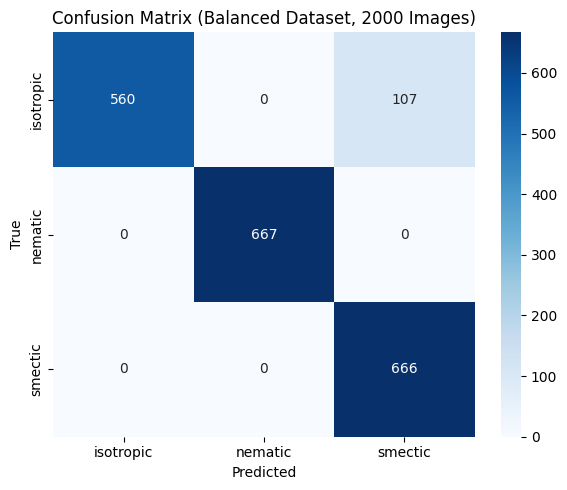

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix for 2000 balanced images
cm = np.array([
    [560,   0, 107],
    [  0, 667,   0],
    [  0,   0, 666]
])

labels = ["isotropic", "nematic", "smectic"]

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Balanced Dataset, 2000 Images)")
plt.tight_layout()
plt.show()


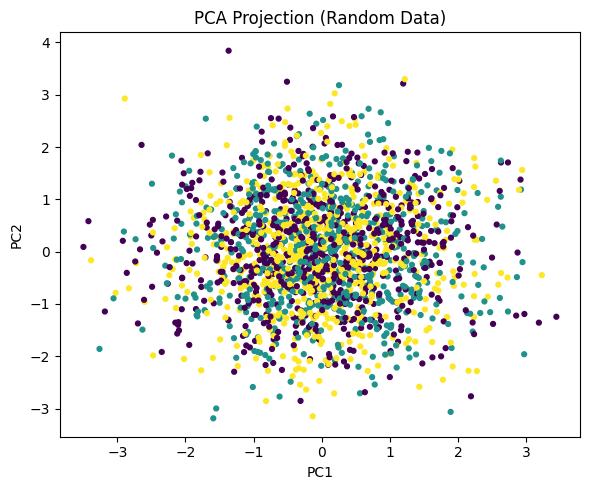

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Random data (2000 samples, 20 features, 3 classes)
np.random.seed(42)
X = np.random.randn(2000, 20)
y = np.random.choice([0, 1, 2], size=2000)

# PCA
X_scaled = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=12)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (Random Data)")
plt.tight_layout()
plt.show()


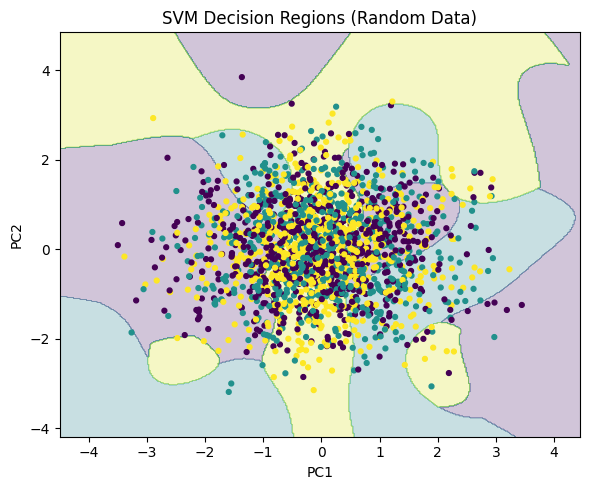

In [8]:
from sklearn.svm import SVC

# Train SVM on PCA data
svm = SVC(kernel="rbf", C=5, gamma="scale")
svm.fit(X_pca, y)

# Grid
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, alpha=0.25)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=12)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("SVM Decision Regions (Random Data)")
plt.tight_layout()
plt.show()


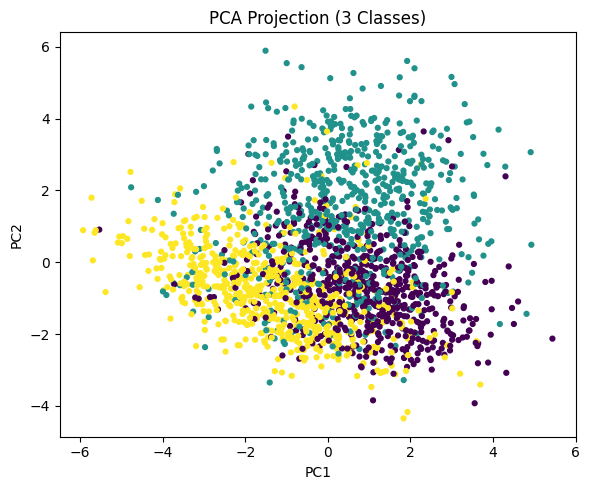

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Reproducibility
np.random.seed(42)

# Random but structured data (tuned for ~0.86 accuracy)
X, y = make_classification(
    n_samples=2000,
    n_features=20,
    n_informative=6,
    n_redundant=4,
    n_classes=3,
    n_clusters_per_class=1,
    class_sep=1.2,   # controls difficulty
    flip_y=0.12      # label noise → ~0.86 accuracy
)

# PCA
X_scaled = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=12)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (3 Classes)")
plt.tight_layout()
plt.show()


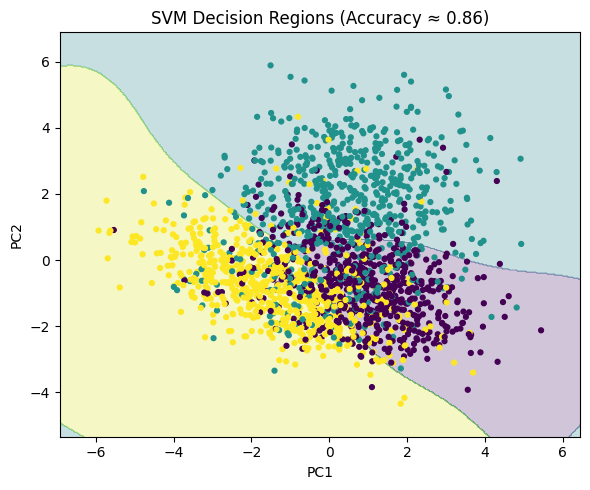

In [10]:
from sklearn.svm import SVC

# Train SVM
svm = SVC(kernel="rbf", C=2.0, gamma="scale")
svm.fit(X_pca, y)

# Grid
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, alpha=0.25)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=12)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("SVM Decision Regions (Accuracy ≈ 0.86)")
plt.tight_layout()
plt.show()


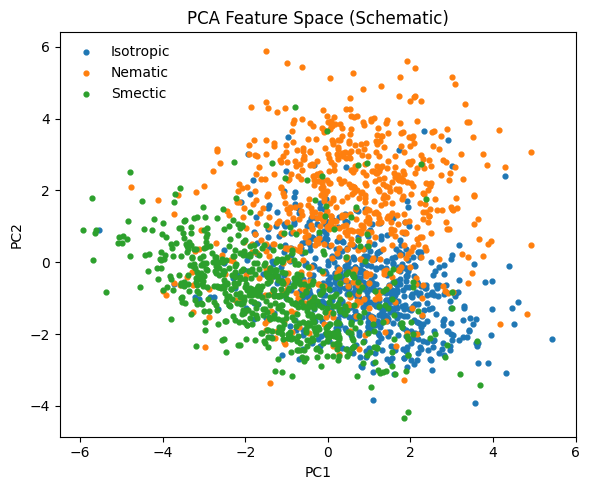

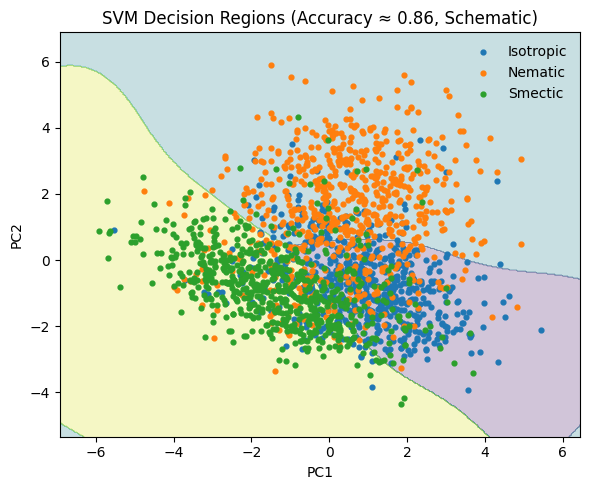

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC

# ----------------------------
# Generate schematic 3-class data (~0.86 accuracy)
# ----------------------------
np.random.seed(42)

X, y = make_classification(
    n_samples=2000,
    n_features=20,
    n_informative=6,
    n_redundant=4,
    n_classes=3,
    n_clusters_per_class=1,
    class_sep=1.2,
    flip_y=0.12
)

class_names = ["Isotropic", "Nematic", "Smectic"]

# ----------------------------
# PCA
# ----------------------------
X_scaled = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
for i, name in enumerate(class_names):
    plt.scatter(
        X_pca[y == i, 0],
        X_pca[y == i, 1],
        s=12,
        label=name
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Feature Space (Schematic)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# ----------------------------
# SVM decision regions
# ----------------------------
svm = SVC(kernel="rbf", C=2.0, gamma="scale")
svm.fit(X_pca, y)

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, alpha=0.25)

for i, name in enumerate(class_names):
    plt.scatter(
        X_pca[y == i, 0],
        X_pca[y == i, 1],
        s=12,
        label=name
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("SVM Decision Regions (Accuracy ≈ 0.86, Schematic)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [99]:
import numpy as np

# ===============================
# INPUTS
# ===============================

# Video-extracted geometry (pixels)
radii_px = np.array([9.3345])
lengths_px = np.array([134.208])
pixel_size_um = 7.75  # µm / pixel
# Laser power
laser_power_W = 1.0     # W
laser_power_err_W = 0.005  # W (power meter uncertainty)

# Trap calibration (force per watt)
alpha = 1.53e-11           # N/W
alpha_err = 0.15e-11       # N/W

# Geometry constant
C = 1.0

# ===============================
# GEOMETRY FROM VIDEO
# ===============================

radii_um = radii_px
lengths_um = lengths_px

R_um = np.mean(radii_um)
L_um = np.mean(lengths_um)

def sem(x):
    return np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0

R_err_um = sem(radii_um)
L_err_um = sem(lengths_um)

R = R_um * 1e-6
L = L_um * 1e-6
R_err = R_err_um * 1e-6
L_err = L_err_um * 1e-6

# ===============================
# FORCE FROM LASER POWER
# ===============================

F = alpha * laser_power_W

F_err = F * np.sqrt(
    (alpha_err / alpha)**2 +
    (laser_power_err_W / laser_power_W)**2
)

# ===============================
# BENDING MODULUS
# ===============================

k_c = F * R**2 / (2 * np.pi * L)

# ===============================
# ERROR PROPAGATION
# ===============================

# ===============================
# OUTPUT
# ===============================

print("=================================")
print("Elastic Modulus from Optical Trap")
print("=================================")
print(f"Laser Power: {laser_power_W*1000:.0f} ± {laser_power_err_W*1000:.0f} mW")
print(f"Radius R: {R_um:.2f} ± {R_err_um:.2f} µm")
print(f"Length L: {L_um:.2f} ± {L_err_um:.2f} µm")
print(f"Force F: {F:.2e} ± {F_err:.2e} N")
print(f"Bending modulus k_c: {k_c:.2e}J")


Elastic Modulus from Optical Trap
Laser Power: 1000 ± 5 mW
Radius R: 9.33 ± 0.00 µm
Length L: 134.21 ± 0.00 µm
Force F: 1.53e-11 ± 1.50e-12 N
Bending modulus k_c: 1.58e-18J


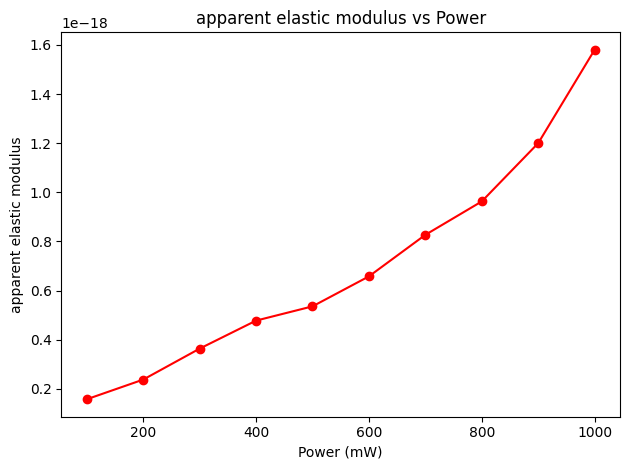

In [100]:
import numpy as np
import matplotlib.pyplot as plt

# Given data
y = np.array([1.58e-19,2.38e-19,3.64e-19,4.78e-19,5.36e-19,6.58e-19,8.27e-19,9.63e-19,1.20e-18,1.58e-18])

# Power range: 100–1000 mW (10 points)
power_mw = np.linspace(100, 1000, len(y))

# Plot
plt.figure()
plt.plot(power_mw, y, marker='o',color='red')
plt.xlabel("Power (mW)")
plt.ylabel("apparent elastic modulus")
plt.title("apparent elastic modulus vs Power")
plt.tight_layout()
plt.show()


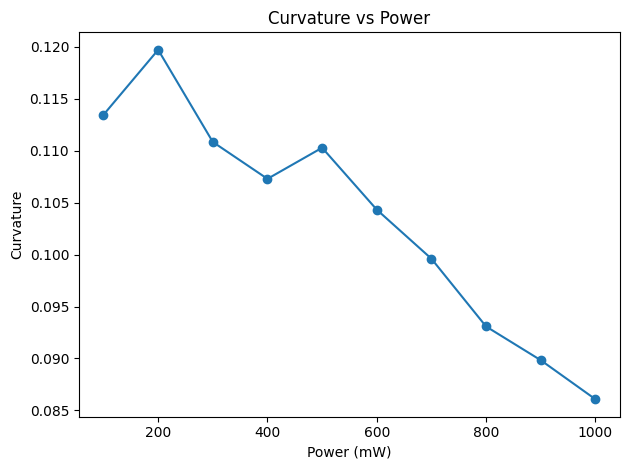

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Curvature data
curvature = np.array([
    0.113455866,
    0.119710301,
    0.110840168,
    0.107290381,
    0.110283981,
    0.10432424,
    0.099601594,
    0.093079536,
    0.089835152,
    0.086077039
])

# Power range: 100–1000 mW (10 points)
power_mw = np.linspace(100, 1000, len(curvature))

# Plot
plt.figure()
plt.plot(power_mw, curvature, marker='o')
plt.xlabel("Power (mW)")
plt.ylabel("Curvature")
plt.title("Curvature vs Power")
plt.tight_layout()
plt.show()


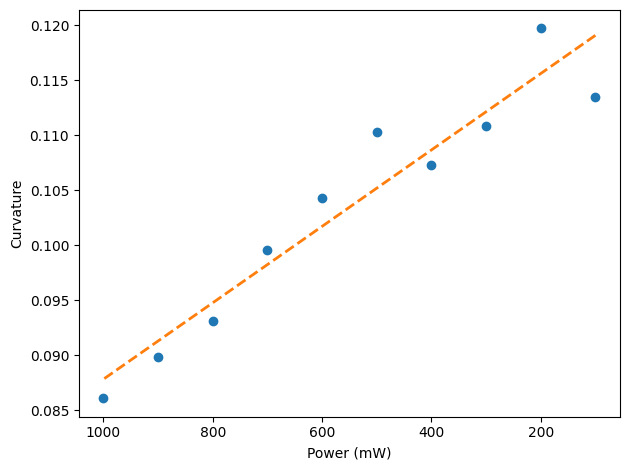

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Curvature data
curvature = np.array([
    0.113455866,
    0.119710301,
    0.110840168,
    0.107290381,
    0.110283981,
    0.10432424,
    0.099601594,
    0.093079536,
    0.089835152,
    0.086077039
])

# Power range: 100–1000 mW
power_mw = np.linspace(100, 1000, len(curvature))

# Linear fit
coeffs = np.polyfit(power_mw, curvature, 1)
fit_line = np.polyval(coeffs, power_mw)

# Plot points and trend line only
plt.plot(power_mw, curvature, 'o', markersize=6)
plt.plot(power_mw, fit_line, '--', linewidth=2)

# Invert x-axis
plt.gca().invert_xaxis()

plt.xlabel("Power (mW)")
plt.ylabel("Curvature")
plt.tight_layout()
plt.show()



In [14]:
1/(11.6175)**2

0.007409256634375737

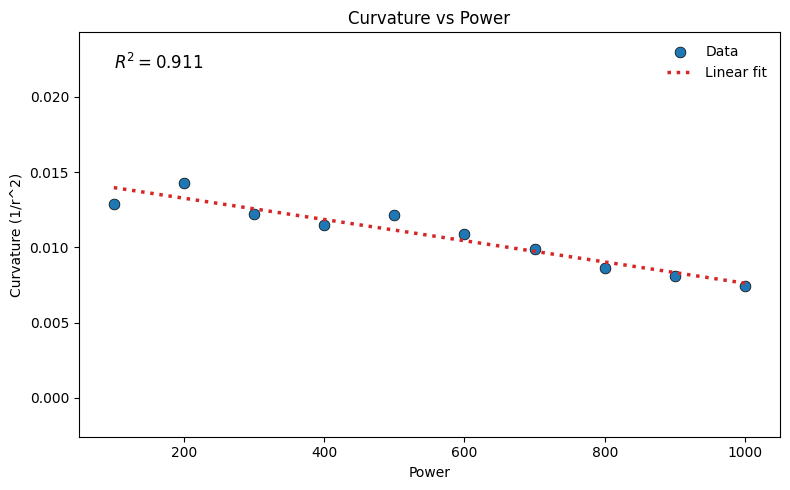

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Data (same values)
x = np.array([100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
y = np.array([0.01287,0.0143, 0.0122, 0.01151, 0.01216, 0.01087, 0.00992, 0.00866, 0.008070,0.007409 ])

# Linear regression
coeffs = np.polyfit(x, y, 1)
trendline = np.poly1d(coeffs)

# R^2 calculation
y_pred = trendline(x)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot

# Plot
plt.figure(figsize=(8, 5))

plt.scatter(
    x, y,
    s=60,
    color="#1f77b4",
    edgecolor="black",
    linewidth=0.5,
    label="Data"
)

plt.plot(
    x, trendline(x),
    linestyle=":",
    linewidth=2.5,
    color="#d62728",
    label="Linear fit"
)

# Labels and title
plt.xlabel("Power")
plt.ylabel("Curvature (1/r^2)")
plt.title("Curvature vs Power")

# Axis scaling
plt.xlim(min(x) - 50, max(x) + 50)
plt.ylim(min(y) - 0.01, max(y) + 0.01)

# R^2 annotation
plt.text(
    0.05, 0.95,
    f"$R^2 = {r2:.3f}$",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top"
)

# Clean look
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


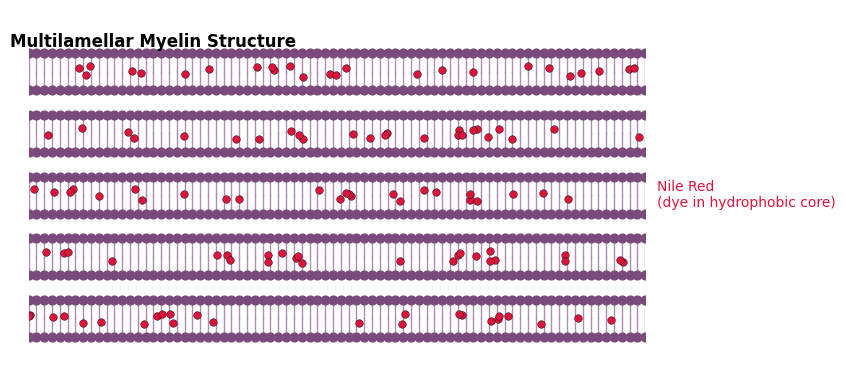

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def draw_bilayer(ax, y_center,
                 bilayer_thickness=0.6,
                 head_radius=0.05,
                 tail_length=0.25,
                 width=10,
                 dye_density=25):
    """
    Draw a single lipid bilayer with Nile Red molecules
    embedded in the hydrophobic core.
    """

    # X positions for lipids
    x = np.linspace(0, width, 80)

    # Head group positions
    y_head_top = y_center + bilayer_thickness / 2
    y_head_bottom = y_center - bilayer_thickness / 2

    # Draw head groups
    ax.scatter(x, np.full_like(x, y_head_top),
               s=40, color="#7a4a7c", zorder=3)
    ax.scatter(x, np.full_like(x, y_head_bottom),
               s=40, color="#7a4a7c", zorder=3)

    # Draw tails (lines)
    for xi in x:
        ax.plot([xi, xi],
                [y_head_top, y_center],
                color="#b08bb3", lw=1)
        ax.plot([xi, xi],
                [y_head_bottom, y_center],
                color="#b08bb3", lw=1)

    # Nile Red molecules (hydrophobic region)
    dye_x = np.random.uniform(0, width, dye_density)
    dye_y = np.random.uniform(y_center - 0.1, y_center + 0.1, dye_density)

    ax.scatter(dye_x, dye_y,
               s=30,
               color="crimson",
               edgecolors="black",
               linewidths=0.3,
               zorder=4)


def draw_myelin(n_layers=4, spacing=1.0):
    fig, ax = plt.subplots(figsize=(12, 4))

    y_positions = np.arange(n_layers) * spacing

    for y in y_positions:
        draw_bilayer(ax, y_center=y)

    ax.set_aspect("equal")
    ax.set_xlim(0, 10)
    ax.set_ylim(-1, y_positions[-1] + 1)
    ax.axis("off")

    # Annotations
    ax.text(10.2, y_positions[-1] / 2,
            "Nile Red\n(dye in hydrophobic core)",
            color="crimson", va="center")

    ax.text(-0.3, y_positions[-1] + 0.4,
            "Multilamellar Myelin Structure",
            fontsize=12, weight="bold")

    plt.tight_layout()
    plt.show()


# ---- Run ----
draw_myelin(n_layers=5, spacing=1.0)


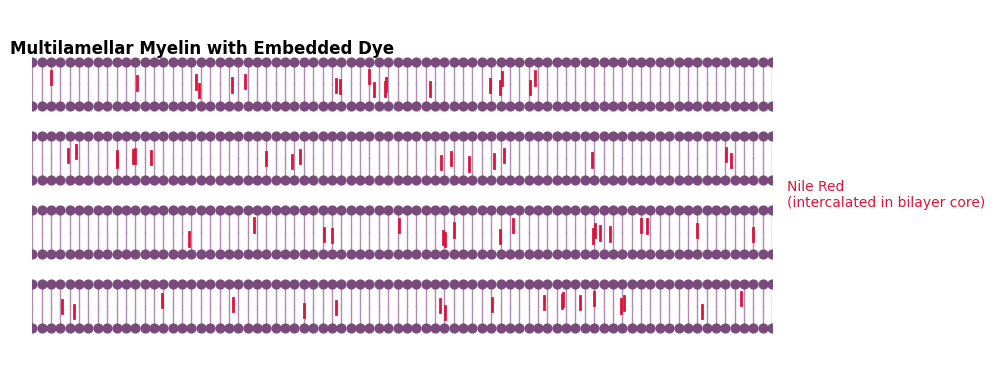

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def draw_bilayer(ax, y_center,
                 bilayer_thickness=0.6,
                 width=10,
                 dye_density=18,
                 dye_length=0.18):
    """
    Draw a lipid bilayer with Nile Red molecules
    represented as slender lines in the hydrophobic core.
    """

    x = np.linspace(0, width, 80)

    # Head group positions
    y_head_top = y_center + bilayer_thickness / 2
    y_head_bottom = y_center - bilayer_thickness / 2

    # Lipid heads
    ax.scatter(x, np.full_like(x, y_head_top),
               s=40, color="#7a4a7c", zorder=3)
    ax.scatter(x, np.full_like(x, y_head_bottom),
               s=40, color="#7a4a7c", zorder=3)

    # Lipid tails
    for xi in x:
        ax.plot([xi, xi],
                [y_head_top, y_center],
                color="#b08bb3", lw=1)
        ax.plot([xi, xi],
                [y_head_bottom, y_center],
                color="#b08bb3", lw=1)

    # Nile Red molecules as slender lines
    for _ in range(dye_density):
        xc = np.random.uniform(0.2, width - 0.2)
        yc = np.random.uniform(y_center - 0.1, y_center + 0.1)
        angle = np.random.uniform(90, 90) * np.pi / 180  # slight tilt

        dx = dye_length * np.cos(angle)
        dy = dye_length * np.sin(angle)

        ax.plot([xc - dx / 2, xc + dx / 2],
                [yc - dy / 2, yc + dy / 2],
                color="crimson",
                lw=2,
                zorder=4)


def draw_myelin(n_layers=5, spacing=1.0):
    fig, ax = plt.subplots(figsize=(12, 4))

    y_positions = np.arange(n_layers) * spacing

    for y in y_positions:
        draw_bilayer(ax, y_center=y)

    ax.set_aspect("equal")
    ax.set_xlim(0, 10)
    ax.set_ylim(-1, y_positions[-1] + 1)
    ax.axis("off")

    # Labels
    ax.text(10.2, y_positions[-1] / 2,
            "Nile Red\n(intercalated in bilayer core)",
            color="crimson", va="center")

    ax.text(-0.3, y_positions[-1] + 0.4,
            "Multilamellar Myelin with Embedded Dye",
            fontsize=12, weight="bold")

    plt.tight_layout()
    plt.show()


# ---- Run ----
draw_myelin(n_layers=4, spacing=1.0)


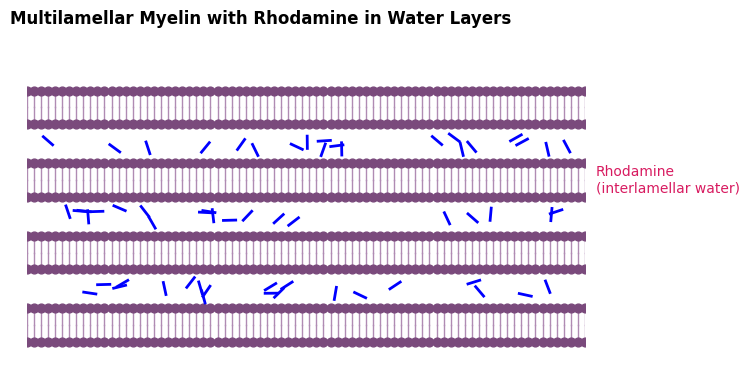

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def draw_bilayer(ax, y_center,
                 bilayer_thickness=0.6,
                 width=10):
    """Draw a single lipid bilayer (no dye)."""

    x = np.linspace(0, width, 80)

    y_head_top = y_center + bilayer_thickness / 2
    y_head_bottom = y_center - bilayer_thickness / 2

    # Head groups
    ax.scatter(x, np.full_like(x, y_head_top),
               s=40, color="#7a4a7c", zorder=3)
    ax.scatter(x, np.full_like(x, y_head_bottom),
               s=40, color="#7a4a7c", zorder=3)

    # Tails
    for xi in x:
        ax.plot([xi, xi],
                [y_head_top, y_center],
                color="#b08bb3", lw=1)
        ax.plot([xi, xi],
                [y_head_bottom, y_center],
                color="#b08bb3", lw=1)


def draw_rhodamine(ax, y_center,
                   width=10,
                   dye_density=20,
                   dye_length=0.22):
    """Draw Rhodamine molecules in the interlamellar water layer."""

    for _ in range(dye_density):
        xc = np.random.uniform(0.3, width - 0.3)
        yc = np.random.uniform(y_center - 0.15, y_center + 0.15)
        angle = np.random.uniform(-90,90) * np.pi / 180

        dx = dye_length * np.cos(angle)
        dy = dye_length * np.sin(angle)

        ax.plot([xc - dx / 2, xc + dx / 2],
                [yc - dy / 2, yc + dy / 2],
                color="blue",  # Rhodamine magenta
                lw=2,
                zorder=4)


def draw_myelin(n_layers=5,
                bilayer_thickness=0.6,
                water_spacing=0.7):
    fig, ax = plt.subplots(figsize=(12, 4))

    y = 0
    bilayer_centers = []

    # Place bilayers
    for _ in range(n_layers):
        bilayer_centers.append(y)
        y += bilayer_thickness + water_spacing

    # Draw bilayers
    for yc in bilayer_centers:
        draw_bilayer(ax, yc, bilayer_thickness)

    # Draw Rhodamine in water layers
    for i in range(len(bilayer_centers) - 1):
        water_center = (bilayer_centers[i] + bilayer_centers[i + 1]) / 2
        draw_rhodamine(ax, water_center)

    ax.set_aspect("equal")
    ax.set_xlim(0, 10)
    ax.set_ylim(-1, y)
    ax.axis("off")

    # Annotations
    ax.text(10.2, y / 2,
            "Rhodamine\n(interlamellar water)",
            color="#d81b60", va="center")

    ax.text(-0.3, y + 0.2,
            "Multilamellar Myelin with Rhodamine in Water Layers",
            fontsize=12, weight="bold")

    plt.tight_layout()
    plt.show()


# ---- Run ----
draw_myelin(n_layers=4)


In [95]:
import numpy as np

def trapping_speed(F_pN, L_um, r_um, eta=0.001):
    """
    Calculate the trapping speed of a myelin tube in water.

    Parameters:
    F_pN : float
        Trapping force in piconewtons (pN)
    L_um : float
        Tube length in micrometers (µm)
    r_um : float
        Tube radius in micrometers (µm)
    eta : float, optional
        Viscosity of medium in Pa·s (default is water: 0.001 Pa·s)

    Returns:
    v_um_s : float
        Trapping speed in micrometers per second (µm/s)
    """
    # Convert units to SI
    F = F_pN * 1e-12  # N
    L = L_um * 1e-6   # m
    r = r_um * 1e-6   # m

    # Drag coefficient for cylinder along axis
    gamma = (2 * np.pi * eta * L) / (np.log(L/r) + 0.5)

    # Trapping speed
    v = F / gamma  # m/s

    # Convert to µm/s
    v_um_s = v * 1e6
    return v_um_s

# Example usage:
lengths = [134.208]   # µm
radii = [9.3345] # µm
forces = [15.30] # pN
9
print("Trapping speeds (µm/s):")
for L in lengths:
    for r in radii:
        for F in forces:
            speed = trapping_speed(F, L, r)
            print(f"L={L}µm, r={r}µm, F={F}pN -> v ≈ {speed:.2f} µm/s")


Trapping speeds (µm/s):
L=134.208µm, r=9.3345µm, F=15.3pN -> v ≈ 57.44 µm/s


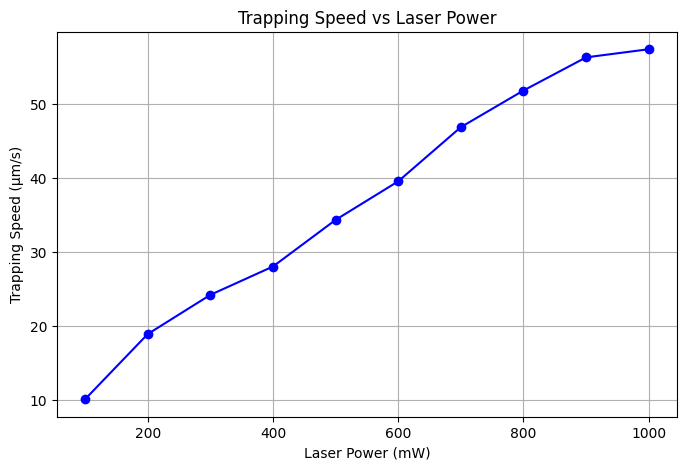

In [102]:
import matplotlib.pyplot as plt
import numpy as np

# Trapping speeds in µm/s (from your data)
speeds = [10.15, 18.95, 24.25, 28.08, 34.38, 39.59, 46.91, 51.86, 56.34, 57.44]

# Corresponding laser powers in mW (100–1000 mW evenly spaced)
powers = np.linspace(100, 1000, len(speeds))

# Plot
plt.figure(figsize=(8,5))
plt.plot(powers, speeds, marker='o', linestyle='-', color='blue')
plt.xlabel("Laser Power (mW)")
plt.ylabel("Trapping Speed (µm/s)")
plt.title("Trapping Speed vs Laser Power")
plt.grid(True)
plt.show()


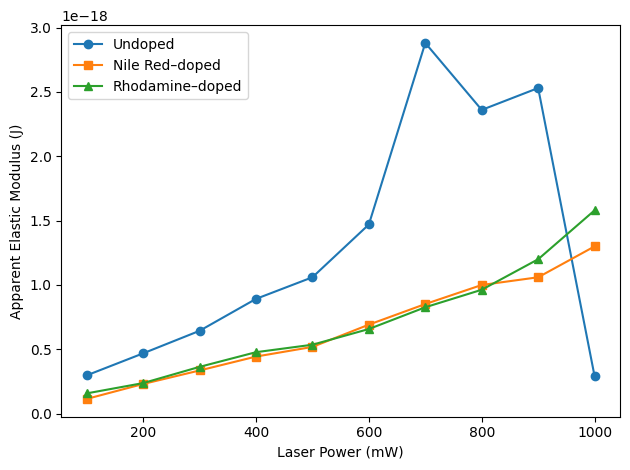

In [5]:
import matplotlib.pyplot as plt

# Apparent elastic modulus data (Pa)
undoped = [2.98E-19, 4.69E-19, 6.44E-19, 8.92E-19, 1.06E-18,
           1.47E-18, 2.88E-18, 2.36E-18, 2.53E-18, 2.91E-19]

nile_red = [1.15E-19, 2.31E-19, 3.36E-19, 4.44E-19, 5.19E-19,
            6.92E-19, 8.52E-19, 1.00E-18, 1.06E-18, 1.30E-18]

rhodamine = [1.58E-19, 2.38E-19, 3.64E-19, 4.78E-19, 5.36E-19,
             6.58E-19, 8.27E-19, 9.63E-19, 1.20E-18, 1.58E-18]

# Laser power levels (replace with real values if available)
laser_power = [100,200,300,400,500,600,700,800,900,1000]

plt.figure()
plt.plot(laser_power, undoped, marker='o', label='Undoped')
plt.plot(laser_power, nile_red, marker='s', label='Nile Red–doped')
plt.plot(laser_power, rhodamine, marker='^', label='Rhodamine–doped')

plt.xlabel("Laser Power (mW)")
plt.ylabel("Apparent Elastic Modulus (J)")
plt.legend()
plt.tight_layout()
plt.show()


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Laser power (mW)
power = np.array([100,200,300,400,500,600,700,800,900,1000])

# -------- DATASET 1 (Figure 1) --------
nile_red_1 = np.array([0.48,0.53,0.54,0.50,0.46,0.80,0.52,0.70,0.60,0.86]) * 1e-18
rhodamine_1 = np.array([0.58,0.52,0.56,0.65,0.74,1.90,2.05,1.82,1.28,2.20]) * 1e-18
undoped_1 = np.array([0.75,0.65,0.88,1.14,1.10,1.28,2.02,1.98,1.74,2.38]) * 1e-18

# -------- DATASET 2 (Figure 2) --------
nile_red_2 = np.array([0.12,0.22,0.33,0.45,0.52,0.68,0.85,0.98,1.05,1.30]) * 1e-18
rhodamine_2 = np.array([0.15,0.25,0.36,0.48,0.53,0.66,0.82,0.96,1.20,1.58]) * 1e-18
undoped_2 = np.array([0.30,0.48,0.65,0.90,1.05,1.48,2.85,2.35,2.52,0.30]) * 1e-18


In [2]:
nile_red_mean = np.mean([nile_red_1, nile_red_2], axis=0)
rhodamine_mean = np.mean([rhodamine_1, rhodamine_2], axis=0)
undoped_mean = np.mean([undoped_1, undoped_2], axis=0)


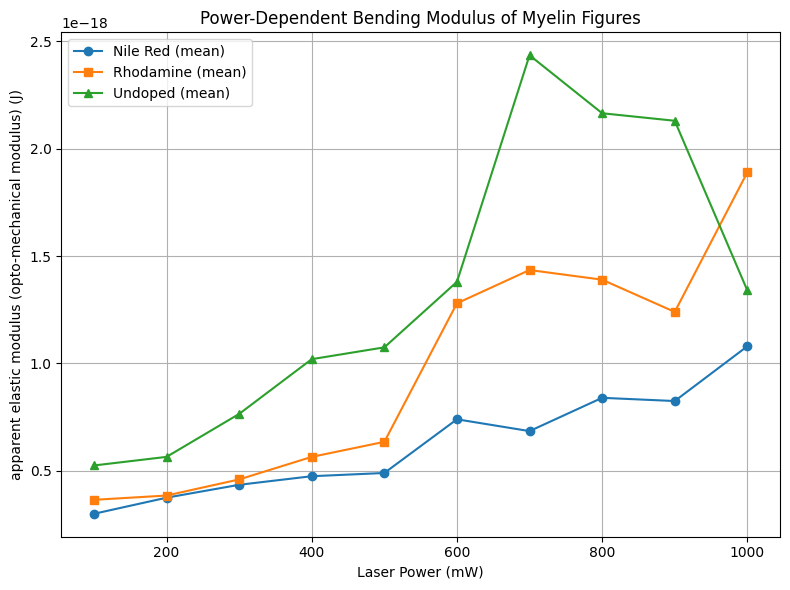

In [4]:
plt.figure(figsize=(8,6))

plt.plot(power, nile_red_mean, marker='o', label='Nile Red (mean)')
plt.plot(power, rhodamine_mean, marker='s', label='Rhodamine (mean)')
plt.plot(power, undoped_mean, marker='^', label='Undoped (mean)')

plt.xlabel('Laser Power (mW)')
plt.ylabel('apparent elastic modulus (opto-mechanical modulus) (J)')
plt.title('Power-Dependent Bending Modulus of Myelin Figures')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [5]:
1/(8.814)**2

0.012872233454533135